In [ ]:
import zipfile

with zipfile.ZipFile('/content/animal.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
!ls


animal.zip  data  download.jpg	images.jpg  sample_data


In [ ]:
import pandas as pd
df = pd.read_csv('data/train.csv')
df.head()

,image:FILE,category
0,train/cat/Sphynx_159_jpg.rf.022528b23ac690c34a...,0
1,train/cat/Persian_139_jpg.rf.0e67f7e0a76dc49d0...,0
2,train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae...,0
3,train/cat/Bombay_140_jpg.rf.15757f698af74453f3...,0
4,train/cat/Persian_128_jpg.rf.16da80c477d1ca2bc...,0


In [ ]:
import os
import shutil


cats_folder = 'data/train/cats'
cat_folder = 'data/train/cat'

if os.path.exists(cats_folder):
    for file in os.listdir(cats_folder):
        shutil.move(os.path.join(cats_folder, file), os.path.join(cat_folder, file))
    os.rmdir(cats_folder)  # removes the now-empty 'cats' folder
    print("Moved all images from 'cats' to 'cat'")


dogs_folder = 'data/train/dogs'
dog_folder = 'data/train/dog'

if os.path.exists(dogs_folder):
    for file in os.listdir(dogs_folder):
        shutil.move(os.path.join(dogs_folder, file), os.path.join(dog_folder, file))
    os.rmdir(dogs_folder)
    print("Moved all images from 'dogs' to 'dog'")


for folder_name in os.listdir('data/train'):
    folder_path = os.path.join('data/train', folder_name)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder_name}: {count} images")


Moved all images from 'cats' to 'cat'
Moved all images from 'dogs' to 'dog'
dog: 458 images
cat: 374 images


In [ ]:

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, RandomFlip, RandomRotation, RandomZoom

AUTOTUNE = tf.data.AUTOTUNE


train_ds = keras.utils.image_dataset_from_directory(
    directory='data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='training',
    seed=123
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='validation',
    seed=123
)

class_names = train_ds.class_names
print("Class names:", class_names)


Found 832 files belonging to 2 classes.
Using 666 files for training.
Found 832 files belonging to 2 classes.
Using 166 files for validation.
Class names: ['cat', 'dog']


In [ ]:
# Normalize
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process).cache().prefetch(AUTOTUNE)
validation_ds = validation_ds.map(process).cache().prefetch(AUTOTUNE)


In [ ]:
# Data Augmentation + Model
model = Sequential([
    # Augmentation layers — only active during training
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),

    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3, 3), activation='relu'),   # added extra conv layer
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(train_ds, epochs=30, validation_data=validation_ds)


Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - accuracy: 0.5202 - loss: 5.0187 - val_accuracy: 0.5361 - val_loss: 0.8111
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.4853 - loss: 7.5683 - val_accuracy: 0.4759 - val_loss: 1.6064
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5469 - loss: 6.3869 - val_accuracy: 0.5663 - val_loss: 2.3408
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5391 - loss: 6.2408 - val_accuracy: 0.4398 - val_loss: 1.6135
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5184 - loss: 4.9146 - val_accuracy: 0.4880 - val_loss: 1.2214
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5678 - loss: 3.6083 - val_accuracy: 0.4699 - val_loss: 1.7098
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5458 - loss: 3.0637 - val_accuracy: 0.5361 - val_loss: 1.0597
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5205 - loss: 3.0151 - val_accuracy: 0

In [ ]:
print("\nFinal Train Accuracy:", history.history['accuracy'][-1])
print("Final Val Accuracy:", history.history['val_accuracy'][-1])


Final Train Accuracy: 0.587087094783783
Final Val Accuracy: 0.6144578456878662


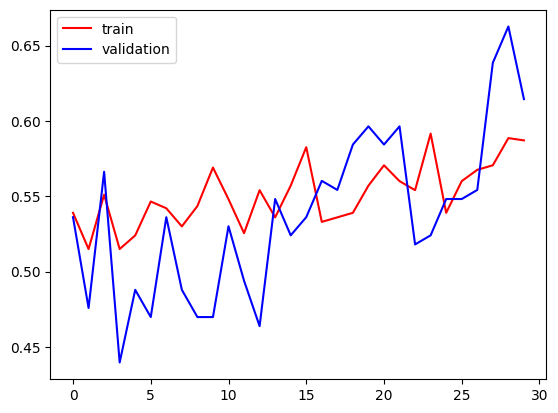

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

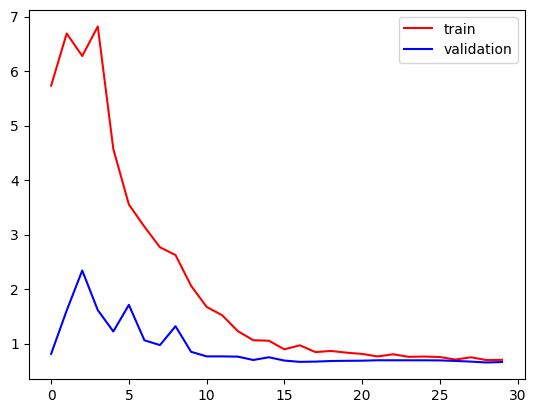

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import cv2
import numpy as np

test_img = cv2.imread('/content/download.jpg')

if test_img is None:
    print("ERROR: Image failed to load. Check the file path.")
else:
    print("Image loaded successfully")
    print("Shape:", test_img.shape)
    print("Dtype:", test_img.dtype)

    test_img = cv2.resize(test_img, (256, 256))
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_input = test_img.reshape((1, 256, 256, 3)).astype(np.float32) / 255.0

    print("Input shape:", test_input.shape)
    print("Input dtype:", test_input.dtype)
    print("Min/Max values:", test_input.min(), test_input.max())

    prediction = model.predict(test_input)
    raw = prediction[0][0]

    print("Class names:", class_names)
    print("Raw prediction value:", raw)

    if raw > 0.5:
        predicted_class = class_names[1]  # dog
        confidence = raw * 100
    else:
        predicted_class = class_names[0]  # cat
        confidence = (1 - raw) * 100

    print(f"Predicted: {predicted_class} with {confidence:.2f}% confidence")

Image loaded successfully
Shape: (168, 300, 3)
Dtype: uint8
Input shape: (1, 256, 256, 3)
Input dtype: float32
Min/Max values: 0.0 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Class names: ['cat', 'dog']
Raw prediction value: 0.47193432
Predicted: cat with 52.81% confidence
